<a href="https://colab.research.google.com/github/braim/nids-tta/blob/cnn-unsw-1000-splinetrue/colab/9-vis/NIDS_CTTA_VIS_8_0_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIDS — AE+Classifier with Few-Shot Layer-Selective CTTA

*   CNN
*   UNSW as Source
*   1000k
*   Spline-Only = True


## Design

**Pre-training:** supervised CE + reconstruction MSE on fully labelled source.

**CTTA strategy — Layer-Selective Updates:**
Three parameter groups are updated during CTTA:
1. **Norm layers** (LayerNorm, GroupNorm) — adapt feature normalisation statistics
2. **Classifier head** — directly moves the decision boundary toward target patterns
3. **Last encoder layer** — adapts the final feature representation

The early encoder layers (source feature extractors) remain frozen.
This gives the CE loss a direct path to update the decision boundary
while protecting source representations from catastrophic forgetting.

**Three loss signals per batch (all requiring only 1% labelled pool):**
1. Supervised CE on labelled pool — moves decision boundary to target domain
2. Entropy minimisation on stream — increases prediction confidence
3. Reconstruction on pool — keeps representations grounded

## Architectures
| `ARCH` | Description |
|---|---|
| `'kan'` | KAN encoder/decoder + linear classifier |
| `'cnn'` | CNN encoder/decoder + linear classifier |

## Hyperparameters
| Parameter | Description |
|---|---|
| `RECON_W` | Reconstruction weight during pre-training |
| `FEW_SHOT_RATIO` | Fraction of target data used as labelled pool |
| `FEW_SHOT_W` | Supervised CE weight during CTTA |
| `TTA_LR` | Learning rate for layer-selective updates |
| `TTA_STEPS` | Gradient steps per batch |
| `ENTROPY_W` | Entropy minimisation weight |
| `RECON_W_TTA` | Reconstruction weight during CTTA |

In [ ]:
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
!pip install -q polars kagglehub

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports & Configuration

In [ ]:
import os, gc, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from efficient_kan import KAN
from datetime import datetime,timezone
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
############################ TO CHANGE ACROSS RUNS #############################
# ── Architecture ──────────────────────────────────────────────────────────────
ARCH            = 'cnn'      # 'kan' | 'cnn'
SPLINE_TRUE      = True

# ── Datasets ──────────────────────────────────────────────────────────────────
SOURCE_DATASET  = 'seyhed/nf-ton-iot-v3'
TARGET1_DATASET = 'seyhed/nf-unsw-nb15-v3'
TARGET2_DATASET = 'seyhed/nf-cicids2018-v3'

SOURCE_NAME     = 'ToN-IoT'
TARGET1_NAME    = 'UNSW-NB15'
TARGET2_NAME    = 'CICIDS2018'

# ── Data ──────────────────────────────────────────────────────────────────────
SAMPLE_N        = 1000_000
################################################################################
BATCH_SIZE      = 256
TTA_BATCH_SIZE  = 512        # larger batches = more stable gradient estimates

# ── Model ─────────────────────────────────────────────────────────────────────
LATENT_DIM      = 32

# ── Pre-training ──────────────────────────────────────────────────────────────
PRETRAIN_EPOCHS = 20
PRETRAIN_LR     = 1e-3
WEIGHT_DECAY    = 1e-4
RECON_W         = 0.5        # reconstruction regularises encoder for transfer

# ── CTTA ──────────────────────────────────────────────────────────────────────
FEW_SHOT_RATIO  = 0.001       # fraction of target used as benign pool
FEW_SHOT_W      = 1.0        # supervised CE weight during CTTA
TTA_LR          = 1e-2       # higher lr is fine — only norm params updated
TTA_STEPS       = 1
ENTROPY_W       = 1.0        # entropy minimisation weight
RECON_W_TTA     = 0.5        # reconstruction on benign pool weight
# from google.colab import drive
# drive.mount('/content/drive')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device={device} | Arch={ARCH} | [SOURCE]={SOURCE_NAME} | Size={SAMPLE_N} | Last Layer={SPLINE_TRUE}')
print(f"Last exec: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%SZ')}")

Device=cpu | Arch=cnn | [SOURCE]=ToN-IoT | Size=1000000 | Last Layer=True
Last exec: 2026-05-14 04:44:31Z


## 2. Data Loading & Preprocessing

In [ ]:
def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    """Derive flow-level features and drop identifier/label columns."""
    if 'FLOW_END_MILLISECONDS' in df.columns and 'FLOW_START_MILLISECONDS' in df.columns:
        df = df.with_columns(
            (pl.col('FLOW_END_MILLISECONDS') - pl.col('FLOW_START_MILLISECONDS')).alias('FLOW_DURATION')
        )
    else:
        df = df.with_columns(pl.lit(0).alias('FLOW_DURATION'))
    if 'IN_BYTES' in df.columns and 'IN_PKTS' in df.columns:
        df = df.with_columns(
            (pl.col('IN_BYTES') / (pl.col('IN_PKTS') + 1e-5)).alias('BYTES_PER_PKT')
        )
    log_cols = ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION', 'SRC_TO_DST_IAT_MAX', 'DST_TO_SRC_IAT_MAX']
    existing = [c for c in log_cols if c in df.columns]
    if existing:
        df = df.with_columns([pl.col(c).log1p() for c in existing])
    drop_cols = [
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
        'Label', 'Attack', 'label', 'attack', 'Date',
    ]
    df = df.drop([c for c in drop_cols if c in df.columns])
    return df


def load_dataset(dataset_name: str, sample_n: int = None):
    """Download dataset and return (X, y). Uses random sampling."""
    print(f'[Data] Loading {dataset_name} ...')
    path = kagglehub.dataset_download(dataset_name)
    csv_files = [
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    ]
    df = pl.scan_csv(csv_files[0]).collect(engine='streaming')
    if sample_n and sample_n < df.height:
        df = df.sample(n=sample_n, seed=SEED)
    label_col = next((c for c in df.columns if c.lower() == 'label'), None)
    y = df[label_col].to_numpy().astype(np.int64) if label_col else np.zeros(df.height, dtype=np.int64)
    df = engineer_features(df)
    X  = df.to_numpy().astype(np.float32)
    X  = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   -> Shape: {X.shape} | Attack rate: {np.mean(y):.2%}')
    return X, y


def make_source_loaders(X, y):
    """
    Stratified 80/20 split. Scaler fitted on full training split.
    Training loader contains all labelled samples (benign + attack).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_tr)
    X_tr   = np.clip(scaler.transform(X_tr).astype(np.float32), -1, 1)
    X_te   = np.clip(scaler.transform(X_te).astype(np.float32), -1, 1)
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    loader_tr = DataLoader(train_ds, batch_size=BATCH_SIZE,     shuffle=True)
    loader_te = DataLoader(test_ds,  batch_size=TTA_BATCH_SIZE, shuffle=False)
    return loader_tr, loader_te, scaler


def make_target_loaders(X, y, external_scaler=None):
    """
    Fit a fresh MinMaxScaler on the full target dataset (no label leakage).

    Stratified split into:
      pool_loader   : FEW_SHOT_RATIO of data, labelled (both classes preserved)
      stream_loader : remaining data, labels kept for evaluation only

    The pool is used for supervised CE anchoring during CTTA.
    Real-world justification: the pool represents a brief initial analyst
    review period at deployment — a realistic assumption.
    """


    # Stratified split — both classes represented in pool
    X_pool, X_stream, y_pool, y_stream = train_test_split(
    X, y,
    test_size=(1 - FEW_SHOT_RATIO),
    random_state=SEED,
    stratify=y,
    )
    scaler   = external_scaler if external_scaler is not None else MinMaxScaler(feature_range=(-1, 1)).fit(X_pool)

    X_pool   = np.clip(scaler.transform(X_pool).astype(np.float32), -1, 1)
    X_stream = np.clip(scaler.transform(X_stream).astype(np.float32), -1, 1)

    pool_ds   = TensorDataset(torch.from_numpy(X_pool),   torch.from_numpy(y_pool))
    stream_ds = TensorDataset(torch.from_numpy(X_stream), torch.from_numpy(y_stream))

    pool_loader   = DataLoader(pool_ds,   batch_size=BATCH_SIZE,     shuffle=True)
    stream_loader = DataLoader(stream_ds, batch_size=TTA_BATCH_SIZE, shuffle=False)

    print(f'   -> Pool: {len(y_pool)} samples '
          f'(attack rate: {np.mean(y_pool):.2%}) | '
          f'Stream: {len(y_stream)} '
          f'(attack rate: {np.mean(y_stream):.2%})')
    return pool_loader, stream_loader


## 3. Model Architectures

In [ ]:
class KanAEClassifier(nn.Module):
    """
    Shared KAN encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (KAN)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (KAN)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder    = KAN([input_dim, 64, latent_dim], grid_range=[-1, 1])
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder    = KAN([latent_dim, 64, input_dim], grid_range=[-1, 1])

    def forward(self, x):
        z = self.ln(self.encoder(x))
        return self.classifier(z), self.decoder(z), z



class TabTransformerAEClassifier(nn.Module):
    """
    Shared TabTransformer encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (Attention + Linear)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (Linear)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32,
                n_heads: int = 4, d_token: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.d_token   = d_token
        # Each scalar feature -> d_token vector (shared linear + per-feature bias)
        self.feature_proj = nn.Linear(1, d_token, bias=False)
        self.feature_bias = nn.Parameter(torch.randn(input_dim, d_token) * 0.02)
        self.ln1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(d_token, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 4), nn.GELU(),
            nn.Linear(d_token * 4, d_token),
        )
        self.encoder_out = nn.Linear(d_token, latent_dim)
        self.ln          = nn.LayerNorm(latent_dim)
        self.classifier  = nn.Linear(latent_dim, 2)
        self.decoder     = nn.Sequential(
            nn.Linear(latent_dim, d_token),
            nn.LayerNorm(d_token), nn.GELU(),
            nn.Linear(d_token, input_dim),
        )

    def forward(self, x):
        # x: (B, D) -> tokens: (B, D, d_token)
        tokens = self.feature_proj(x.unsqueeze(-1)) + self.feature_bias.unsqueeze(0)
        tokens = self.ln1(tokens)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = tokens + attn_out
        tokens = self.ln2(tokens)
        tokens = tokens + self.ffn(tokens)
        pooled = tokens.mean(dim=1)
        z = self.ln(self.encoder_out(pooled))
        return self.classifier(z), self.decoder(z), z

class CnnAEClassifier(nn.Module):
    """
    Shared CNN encoder → classifier head + decoder head.

    Each feature becomes its own channel (seq len=1). Pointwise Conv1d.
    GroupNorm(1, C) works with seq len=1 and is robust to variable attack rates.

    Encoder:    input_dim -> 64 -> latent_dim  (Conv1d)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (ConvTranspose1d)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.Conv1d(64, latent_dim, kernel_size=1),
        )
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.ConvTranspose1d(64, input_dim, kernel_size=1),
        )

    def forward(self, x):
        z     = self.ln(self.encoder(x.unsqueeze(-1)).squeeze(-1))
        recon = self.decoder(z.unsqueeze(-1)).squeeze(-1)
        return self.classifier(z), recon, z


def build_model(arch: str, input_dim: int) -> nn.Module:
    if arch == 'kan':
        return KanAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'cnn':
        return CnnAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'tab':
        return TabTransformerAEClassifier(input_dim, LATENT_DIM)
    else:
        raise ValueError(f"Unknown ARCH={arch!r}. Choose 'kan', 'cnn', or 'tab'")


def get_trainable_params(model: nn.Module):
    """
    Return parameters for layer-selective CTTA updates.

    Updated:
      - All LayerNorm / GroupNorm parameters (normalisation statistics)
      - Classifier head (decision boundary can shift toward target)
      - Last encoder layer (final feature representation can adapt)

    Frozen:
      - All early encoder layers (source feature extractors)
      - Decoder (not needed for classification)

    This gives CE a direct path to move the decision boundary while
    protecting source representations from catastrophic forgetting.
    """
    params = []
    seen   = set()

    def add(p):
        if id(p) not in seen:
            seen.add(id(p))
            params.append(p)

    # 1. Norm layers (encoder + classifier only, not decoder)
    for name, module in model.named_modules():
        if 'decoder' in name:
            continue
        if isinstance(module, (nn.LayerNorm, nn.GroupNorm)):
            for p in module.parameters():
                add(p)

    # 2. Classifier head
    for p in model.classifier.parameters():
        add(p)

    # 3. Last encoder layer
    if isinstance(model, KanAEClassifier):
        # KAN — last KANLayer
        if hasattr(model.encoder, 'layers') and len(model.encoder.layers) > 0:
            for p in model.encoder.layers[-1].parameters():
                add(p)
    elif isinstance(model, CnnAEClassifier):
        # CNN — last Conv1d in sequential
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                add(p)
    elif isinstance(model, TabTransformerAEClassifier):
        # TabTransformer — encoder_out projection layer
        for p in model.encoder_out.parameters():
            add(p)

    return params


## 4. Training & Evaluation

In [ ]:
class KAN_Retention:
    """
    KAN-specific Elastic Weight Consolidation (EWC).
    Calculates the Fisher Information for specific KAN parameters (e.g., splines)
    to penalize drastic changes to important learned shapes during CTTA.
    """
    def __init__(self, model, dataloader, device, params_to_protect):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.params_to_protect = params_to_protect

        # 1. Store the optimal source parameters (theta_source)
        self.optpar_dict = {}
        for p in self.params_to_protect:
            self.optpar_dict[id(p)] = p.data.clone().detach()

        # 2. Compute Fisher Information Matrix (diagonal approximation)
        print('[KAN Retention] Computing Fisher Information on Source Data...')
        self.fisher_dict = self._compute_fisher()
        print('[KAN Retention] Initialization Complete.')

    def _compute_fisher(self):
        fisher_dict = {id(p): torch.zeros_like(p.data) for p in self.params_to_protect}

        # Ensure we can compute gradients for these parameters
        for p in self.params_to_protect:
            p.requires_grad_(True)

        self.model.eval() # Eval mode for stability
        ce_crit = nn.CrossEntropyLoss()

        num_samples = 0
        for x, y in self.dataloader:
            x, y = x.to(self.device), y.to(self.device)
            self.model.zero_grad()

            logits, _, _ = self.model(x)
            loss = ce_crit(logits, y)
            loss.backward()

            # Accumulate squared gradients (Fisher diagonal)
            for p in self.params_to_protect:
                if p.grad is not None:
                    fisher_dict[id(p)] += (p.grad.data ** 2) * x.size(0)

            num_samples += x.size(0)

        # Average over all samples
        for p in self.params_to_protect:
            fisher_dict[id(p)] /= num_samples

        return fisher_dict

    def penalty(self):
        """
        Computes the EWC penalty: sum( Fisher * (theta - theta_source)^2 )
        """
        loss = 0.0
        for p in self.params_to_protect:
            fisher = self.fisher_dict[id(p)]
            optpar = self.optpar_dict[id(p)]
            loss += (fisher * (p - optpar) ** 2).sum()
        return loss

In [ ]:
def pretrain_source(model, loader, epochs, device):
    """
    Joint supervised + reconstruction pre-training.
    Loss = CrossEntropy(logits, y) + RECON_W * MSE(recon, x)
    ALL parameters updated — standard supervised training.
    """
    optimizer = optim.Adam(model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    ce_crit   = nn.CrossEntropyLoss()
    mse_crit  = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss, correct, total = 0.0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, recon, _ = model(x)
            loss = ce_crit(logits, y) + RECON_W * mse_crit(recon, x)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
        print(f'[Pretrain] Epoch {epoch+1}/{epochs} | '
              f'Loss: {total_loss/len(loader):.4f} | '
              f'Acc: {correct/total:.4f}')


def evaluate(model, loader, device, desc='Eval'):
    """Evaluate using classifier head — argmax of logits."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'[{desc}] F1: {f1:.4f} | Acc: {acc:.4f}')
    return f1

def get_spline_only_params(model):
    """
    Return the minimal-parameter trainable set for CTTA, per architecture.

    For KAN: ONLY the spline parameters of the last encoder layer
             (spline_weight + spline_scaler). base_weight is EXCLUDED —
             it's a linear residual path, not part of the spline.
    For CNN: parameters of the last Conv1d / Linear in the encoder
             (no splines exist in this arch).
    For TabTransformer: parameters of encoder_out, the final projection
             into the latent space (no splines in this arch).

    The kwarg name `spline_only` is kept for backward compatibility, but
    the semantics differ by architecture — for non-KAN it is really
    'last-layer-only'.
    """
    params = []

    if isinstance(model, KanAEClassifier):
        if not hasattr(model.encoder, 'layers') or len(model.encoder.layers) == 0:
            return []
        last = model.encoder.layers[-1]
        if hasattr(last, 'spline_weight') and isinstance(last.spline_weight, torch.nn.Parameter):
            params.append(last.spline_weight)
        if hasattr(last, 'spline_scaler') and isinstance(last.spline_scaler, torch.nn.Parameter):
            params.append(last.spline_scaler)

    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                params.append(p)

    elif isinstance(model, TabTransformerAEClassifier):
        for p in model.encoder_out.parameters():
            params.append(p)

    return params


def run_ctta(model, stream_loader, pool_loader, device, spline_only=False):
    """
    Few-Shot Layer-Selective CTTA.

    FROZEN:  early encoder layers, decoder weights.
    UPDATED: LayerNorm/GroupNorm params, classifier head, last encoder layer.
             In spline_only mode: only last encoder layer spline weights.

    Per stream batch:
      1. Supervised CE on pool batch — anchors decision boundary to target
      2. Entropy minimisation on stream batch — increases prediction confidence
      3. Reconstruction on benign pool samples — prevents representation drift

    Returns (preds, labels, trajectory) on the stream.
    """
    if spline_only:
        train_params = get_spline_only_params(model)
        print(f'[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.')
    else:
        train_params = get_trainable_params(model)


    trainable_ids = {id(p) for p in train_params}
    for p in model.parameters():
        p.requires_grad = (id(p) in trainable_ids)

    print(f'[CTTA] Updating {len(train_params)} param tensors '
          f'({sum(p.numel() for p in train_params)} params). '
          f'All other weights frozen.')

    optimizer = optim.Adam(train_params, lr=TTA_LR)
    ce_crit   = nn.CrossEntropyLoss()
    model.train()

    # Pool cycles indefinitely
    pool_iter = iter(pool_loader)
    def next_pool():
        nonlocal pool_iter
        try:
            return next(pool_iter)
        except StopIteration:
            pool_iter = iter(pool_loader)
            return next(pool_iter)

    all_preds, all_labels = [], []
    trajectory = []
    batch_count = 0
    TRAJ_INTERVAL = 20

    for x_stream, y_stream in stream_loader:
        x_stream = x_stream.to(device)

        for _ in range(TTA_STEPS):
            optimizer.zero_grad()

            # ── 1. Supervised CE on pool batch ────────────────────────────
            x_pool, y_pool = next_pool()
            x_pool = x_pool.to(device)
            y_pool = y_pool.to(device)
            logits_pool, recon_pool, _ = model(x_pool)
            loss_ce    = ce_crit(logits_pool, y_pool)

            # ── 2. Entropy on stream batch ────────────────────────────────
            logits_s, _, _ = model(x_stream)
            probs    = F.softmax(logits_s, dim=1)
            loss_ent = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()

            # ── 3. Reconstruction on pool batch ───────────────────────────
            benign_mask = (y_pool == 0)
            if benign_mask.any():
                loss_recon = F.mse_loss(recon_pool[benign_mask], x_pool[benign_mask])
            else:
                loss_recon = torch.tensor(0.0, device=device)


            loss = (FEW_SHOT_W  * loss_ce   +
                    ENTROPY_W   * loss_ent  +
                    RECON_W_TTA * loss_recon)



            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                optimizer.step()

        # Final inference
        with torch.no_grad():
            model.eval()
            logits_f, _, _ = model(x_stream)
            preds = logits_f.argmax(1).cpu().numpy()
            model.train()

        all_preds.extend(preds)
        all_labels.extend(y_stream.numpy())

        batch_count += 1
        if batch_count % TRAJ_INTERVAL == 0:
            f1_so_far = f1_score(all_labels, all_preds, zero_division=0)
            trajectory.append((batch_count, f1_so_far))

    print('[CTTA] Stream complete.')
    return np.array(all_preds), np.array(all_labels), trajectory


## 5. Load Datasets

In [ ]:
# ── Source: ───────────────────────────────────────────────────────────
X_src, y_src = load_dataset(SOURCE_DATASET, sample_n=SAMPLE_N)
input_dim = X_src.shape[1]
loader_src_train, loader_src_test, source_scaler = make_source_loaders(X_src, y_src)
del X_src, y_src; gc.collect()

# ── Target 1: ──────────────────────────────────────────────────────
X_tgt1, y_tgt1 = load_dataset(TARGET1_DATASET, sample_n=SAMPLE_N)
pool_tgt1, stream_tgt1 = make_target_loaders(X_tgt1, y_tgt1)
# Also build loaders using source scaler for the scaler experiment
pool_tgt1_src_sc, stream_tgt1_src_sc = make_target_loaders(X_tgt1, y_tgt1, external_scaler=source_scaler)
del X_tgt1, y_tgt1; gc.collect()

# ── Target 2: ─────────────────────────────────────────────────────
X_tgt2, y_tgt2 = load_dataset(TARGET2_DATASET, sample_n=SAMPLE_N)
pool_tgt2, stream_tgt2 = make_target_loaders(X_tgt2, y_tgt2)
pool_tgt2_src_sc, stream_tgt2_src_sc = make_target_loaders(X_tgt2, y_tgt2, external_scaler=source_scaler)
del X_tgt2, y_tgt2; gc.collect()

print(f'\n[System] All datasets loaded. Input dim: {input_dim}')

[Data] Loading seyhed/nf-ton-iot-v3 ...
Using Colab cache for faster access to the 'nf-ton-iot-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 38.97%
[Data] Loading seyhed/nf-unsw-nb15-v3 ...
Using Colab cache for faster access to the 'nf-unsw-nb15-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 5.44%
   -> Pool: 1000 samples (attack rate: 5.40%) | Stream: 999000 (attack rate: 5.44%)
   -> Pool: 1000 samples (attack rate: 5.40%) | Stream: 999000 (attack rate: 5.44%)
[Data] Loading seyhed/nf-cicids2018-v3 ...
Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 12.98%
   -> Pool: 1000 samples (attack rate: 13.00%) | Stream: 999000 (attack rate: 12.98%)
   -> Pool: 1000 samples (attack rate: 13.00%) | Stream: 999000 (attack rate: 12.98%)

[System] All datasets loaded. Input dim: 49


## 6. Phase 1 — Source Pre-training

In [ ]:
# checkpoint = torch.load(f'/content/drive/MyDrive/pretrained_{ARCH}_toniot.pt')
# model = build_model(checkpoint['arch'], checkpoint['input_dim']).to(device)
# model.load_state_dict(checkpoint['model_state_dict'])
# print('Model loaded from Drive')


print('=' * 60)
print(f'PHASE 1: SOURCE PRE-TRAINING ({SOURCE_NAME}) | {ARCH.upper()}')
print('=' * 60)

model = build_model(ARCH, input_dim).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_params = get_trainable_params(model)
print(f'[Model] {ARCH} | input_dim={input_dim} | latent_dim={LATENT_DIM} | '
      f'total params={n_params:,} | trainable params={sum(p.numel() for p in trainable_params)}\n')

pretrain_source(model, loader_src_train, epochs=PRETRAIN_EPOCHS, device=device)

PHASE 1: SOURCE PRE-TRAINING (ToN-IoT) | CNN
[Model] cnn | input_dim=49 | latent_dim=32 | total params=10,963 | trainable params=2338

[Pretrain] Epoch 1/20 | Loss: 0.2759 | Acc: 0.8937
[Pretrain] Epoch 2/20 | Loss: 0.2367 | Acc: 0.9073
[Pretrain] Epoch 3/20 | Loss: 0.2271 | Acc: 0.9098
[Pretrain] Epoch 4/20 | Loss: 0.2226 | Acc: 0.9106
[Pretrain] Epoch 5/20 | Loss: 0.2191 | Acc: 0.9118
[Pretrain] Epoch 6/20 | Loss: 0.2157 | Acc: 0.9130
[Pretrain] Epoch 7/20 | Loss: 0.2125 | Acc: 0.9141
[Pretrain] Epoch 8/20 | Loss: 0.2123 | Acc: 0.9140
[Pretrain] Epoch 9/20 | Loss: 0.2100 | Acc: 0.9146
[Pretrain] Epoch 10/20 | Loss: 0.2089 | Acc: 0.9153
[Pretrain] Epoch 11/20 | Loss: 0.2077 | Acc: 0.9157
[Pretrain] Epoch 12/20 | Loss: 0.2076 | Acc: 0.9158
[Pretrain] Epoch 13/20 | Loss: 0.2062 | Acc: 0.9162
[Pretrain] Epoch 14/20 | Loss: 0.2061 | Acc: 0.9164
[Pretrain] Epoch 15/20 | Loss: 0.2053 | Acc: 0.9168
[Pretrain] Epoch 16/20 | Loss: 0.2041 | Acc: 0.9173
[Pretrain] Epoch 17/20 | Loss: 0.2038 | Ac

In [ ]:
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'arch': ARCH,
#     'input_dim': input_dim,
#     'latent_dim': LATENT_DIM,
# }, f'/content/drive/MyDrive/pretrained_{ARCH}_toniot.pt')
# print(f'Saved to Google Drive: pretrained_{ARCH}_toniot.pt')

## 7. Diagnostic — Post-Pretraining

In [ ]:
# Source F1 should be >0.85 before CTTA.
# Zero-shot gives the baseline CTTA should improve from.
model_state = {k: v.clone() for k, v in model.state_dict().items()}
print('[Diagnostic] Source test performance:')
evaluate(model, loader_src_test, device, desc=f'Source ({SOURCE_NAME}) [post-pretrain]')

print('\n[Diagnostic] Zero-shot on targets (no adaptation yet):')
evaluate(model, stream_tgt1, device, desc=f'Target1 ({TARGET1_NAME})  [zero-shot]')
evaluate(model, stream_tgt2, device, desc=f'Target2 ({TARGET2_NAME}) [zero-shot]')

print('\n[Diagnostic] Parameters that will be updated during CTTA:')
ctta_params = get_trainable_params(model)
total_ctta = sum(p.numel() for p in ctta_params)
spline_params = get_spline_only_params(model)
total_spline = sum(p.numel() for p in spline_params)
total_all = sum(p.numel() for p in model.parameters())
print(f'  Full CTTA:   {total_ctta:,} / {total_all:,} params ({total_ctta/total_all:.2%})')
print(f'  Spline-only: {total_spline:,} / {total_all:,} params ({total_spline/total_all:.2%})')

[Diagnostic] Source test performance:
[Source (ToN-IoT) [post-pretrain]] F1: 0.8902 | Acc: 0.9161

[Diagnostic] Zero-shot on targets (no adaptation yet):
[Target1 (UNSW-NB15)  [zero-shot]] F1: 0.0022 | Acc: 0.9448
[Target2 (CICIDS2018) [zero-shot]] F1: 0.0170 | Acc: 0.8648

[Diagnostic] Parameters that will be updated during CTTA:
  Full CTTA:   2,338 / 10,963 params (21.33%)
  Spline-only: 2,080 / 10,963 params (18.97%)


## 8. Phase 2 — Zero-Shot Baseline

In [ ]:
print('=' * 60)
print('SCALER EXPERIMENT: source scaler vs target scaler (zero-shot)')
print('=' * 60)

print('\n[Target scaler] (current default):')
evaluate(model, stream_tgt1, device, desc=f'Target1 ({TARGET1_NAME}) target-scaler')
evaluate(model, stream_tgt2, device, desc=f'Target2 ({TARGET2_NAME})  target-scaler')

print('\n[Source scaler] (same scaler as pre-training):')
evaluate(model, stream_tgt1_src_sc, device, desc=f'Target1 ({TARGET1_NAME}) source-scaler')
evaluate(model, stream_tgt2_src_sc, device, desc=f'Target2 ({TARGET2_NAME})  source-scaler')

SCALER EXPERIMENT: source scaler vs target scaler (zero-shot)

[Target scaler] (current default):
[Target1 (UNSW-NB15) target-scaler] F1: 0.0022 | Acc: 0.9448
[Target2 (CICIDS2018)  target-scaler] F1: 0.0170 | Acc: 0.8648

[Source scaler] (same scaler as pre-training):
[Target1 (UNSW-NB15) source-scaler] F1: 0.0677 | Acc: 0.4258
[Target2 (CICIDS2018)  source-scaler] F1: 0.1144 | Acc: 0.6807


0.11437583646632199

## 9. Phase 3 — CTTA on Target 1

Norm layers, classifier head, and last encoder layer are updated. All other weights are frozen.

In [ ]:
print('=' * 60)
print('FEW-SHOT BASELINE: train from scratch on pool only (no pre-training)')
print('=' * 60)
def few_shot_baseline(pool_loader, stream_loader, input_dim, arch, device, epochs=50):
    torch.manual_seed(SEED)
    fresh_model = build_model(arch, input_dim).to(device)
    optimizer = optim.Adam(fresh_model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    ce_crit = nn.CrossEntropyLoss()

    fresh_model.train()
    for epoch in range(epochs):
        for x, y in pool_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _, _ = fresh_model(x)
            loss = ce_crit(logits, y)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                optimizer.step()

    f1 = evaluate(fresh_model, stream_loader, device, desc=f'Few-shot-only ({arch})')
    del fresh_model
    gc.collect()
    return f1

print(f'\n[Target 1 — {TARGET1_NAME}]')
print('  Target scaler:')
fs_f1_tgt1 = few_shot_baseline(pool_tgt1, stream_tgt1, input_dim, ARCH, device)
print('  Source scaler:')
fs_f1_tgt1_ss = few_shot_baseline(pool_tgt1_src_sc, stream_tgt1_src_sc, input_dim, ARCH, device)

print(f'\n[Target 2 — {TARGET2_NAME}]')
print('  Target scaler:')
fs_f1_tgt2 = few_shot_baseline(pool_tgt2, stream_tgt2, input_dim, ARCH, device)
print('  Source scaler:')
fs_f1_tgt2_ss = few_shot_baseline(pool_tgt2_src_sc, stream_tgt2_src_sc, input_dim, ARCH, device)

FEW-SHOT BASELINE: train from scratch on pool only (no pre-training)

[Target 1 — UNSW-NB15]
  Target scaler:
[Few-shot-only (cnn)] F1: 0.9760 | Acc: 0.9974
  Source scaler:
[Few-shot-only (cnn)] F1: 0.9778 | Acc: 0.9976

[Target 2 — CICIDS2018]
  Target scaler:
[Few-shot-only (cnn)] F1: 0.9317 | Acc: 0.9823
  Source scaler:
[Few-shot-only (cnn)] F1: 0.8735 | Acc: 0.9689


In [ ]:
print('=' * 60)
print(f'PHASE 3: LAYER-SELECTIVE CTTA — Target 1 ({TARGET1_NAME})')
print('=' * 60)

torch.manual_seed(SEED)
model.load_state_dict(model_state)

print('\n[Target scaler]:')
preds_tgt1, labels_tgt1, traj_tgt1_ts = run_ctta(
    model,
    stream_loader = stream_tgt1,
    pool_loader   = pool_tgt1,
    device        = device,
    spline_only=SPLINE_TRUE
)
f1  = f1_score(labels_tgt1, preds_tgt1, zero_division=0)
acc = accuracy_score(labels_tgt1, preds_tgt1)
print(f'[CTTA Target1 — target scaler] F1: {f1:.4f} | Acc: {acc:.4f}')

print('\n[Source scaler]:')
model.load_state_dict(model_state)
preds_tgt1_ss, labels_tgt1_ss, traj_tgt1_ss = run_ctta(
    model,
    stream_loader = stream_tgt1_src_sc,
    pool_loader   = pool_tgt1_src_sc,
    device        = device,
    spline_only=SPLINE_TRUE
)
f1  = f1_score(labels_tgt1_ss, preds_tgt1_ss, zero_division=0)
acc = accuracy_score(labels_tgt1_ss, preds_tgt1_ss)
print(f'[CTTA Target1 — source scaler] F1: {f1:.4f} | Acc: {acc:.4f}')


PHASE 3: LAYER-SELECTIVE CTTA — Target 1 (UNSW-NB15)

[Target scaler]:
[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.
[CTTA] Updating 2 param tensors (2080 params). All other weights frozen.
[CTTA] Stream complete.
[CTTA Target1 — target scaler] F1: 0.9303 | Acc: 0.9928

[Source scaler]:
[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.
[CTTA] Updating 2 param tensors (2080 params). All other weights frozen.
[CTTA] Stream complete.
[CTTA Target1 — source scaler] F1: 0.9475 | Acc: 0.9945


## 10. Phase 4 — CTTA on Target 2

Model is reset to post-pretrain state before this phase
so results are independent of Phase 3.

In [ ]:
print('=' * 60)
print(f'PHASE 4: LAYER-SELECTIVE CTTA — Target 2 ({TARGET2_NAME})')
print('=' * 60)

print('\n[Target scaler]:')
model.load_state_dict(model_state)
preds_tgt2, labels_tgt2, traj_tgt2_ts = run_ctta(
    model,
    stream_loader = stream_tgt2,
    pool_loader   = pool_tgt2,
    device        = device,
    spline_only=SPLINE_TRUE
)
f1  = f1_score(labels_tgt2, preds_tgt2, zero_division=0)
acc = accuracy_score(labels_tgt2, preds_tgt2)
print(f'[CTTA Target2 — target scaler] F1: {f1:.4f} | Acc: {acc:.4f}')

print('\n[Source scaler]:')
model.load_state_dict(model_state)
preds_tgt2_ss, labels_tgt2_ss, traj_tgt2_ss = run_ctta(
    model,
    stream_loader = stream_tgt2_src_sc,
    pool_loader   = pool_tgt2_src_sc,
    device        = device,
    spline_only=SPLINE_TRUE
)
f1  = f1_score(labels_tgt2_ss, preds_tgt2_ss, zero_division=0)
acc = accuracy_score(labels_tgt2_ss, preds_tgt2_ss)
print(f'[CTTA Target2 — source scaler] F1: {f1:.4f} | Acc: {acc:.4f}')


PHASE 4: LAYER-SELECTIVE CTTA — Target 2 (CICIDS2018)

[Target scaler]:
[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.
[CTTA] Updating 2 param tensors (2080 params). All other weights frozen.
[CTTA] Stream complete.
[CTTA Target2 — target scaler] F1: 0.8477 | Acc: 0.9614

[Source scaler]:
[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.
[CTTA] Updating 2 param tensors (2080 params). All other weights frozen.
[CTTA] Stream complete.
[CTTA Target2 — source scaler] F1: 0.8436 | Acc: 0.9608


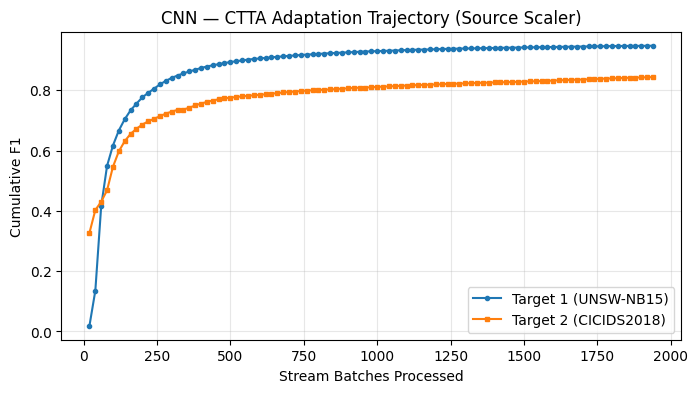

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
if traj_tgt1_ss:
    batches, f1s = zip(*traj_tgt1_ss)
    ax.plot(batches, f1s, label=f'Target 1 ({TARGET1_NAME})', marker='o', markersize=3)
if traj_tgt2_ss:
    batches, f1s = zip(*traj_tgt2_ss)
    ax.plot(batches, f1s, label=f'Target 2 ({TARGET2_NAME})', marker='s', markersize=3)
ax.set_xlabel('Stream Batches Processed')
ax.set_ylabel('Cumulative F1')
ax.set_title(f'{ARCH.upper()} — CTTA Adaptation Trajectory (Source Scaler)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('adaptation_trajectory.png', dpi=200, bbox_inches='tight')
plt.show()

[CTTA] Updating 8 param tensors (2338 params). All other weights frozen.
[CTTA] Stream complete.


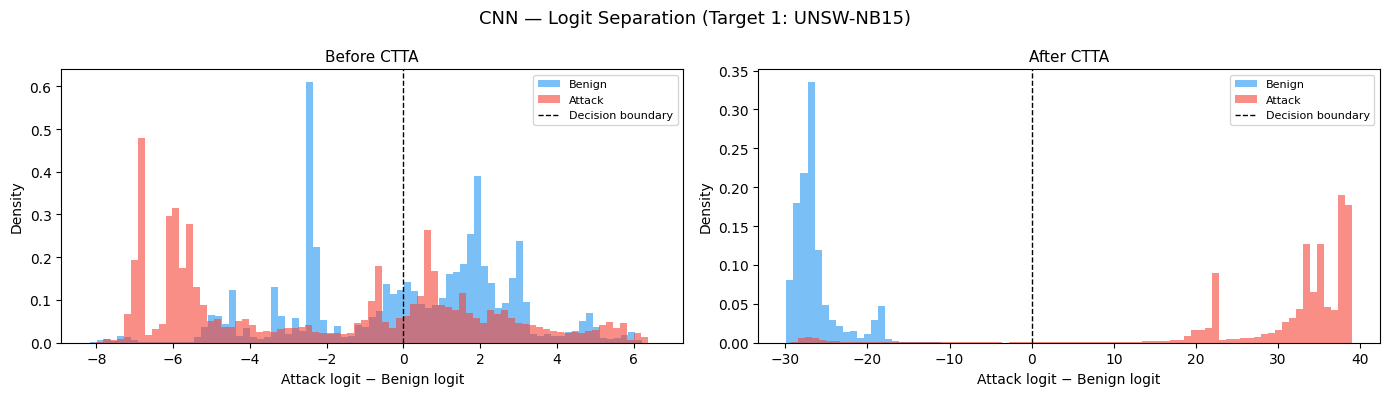

[CTTA] Updating 8 param tensors (2338 params). All other weights frozen.
[CTTA] Stream complete.


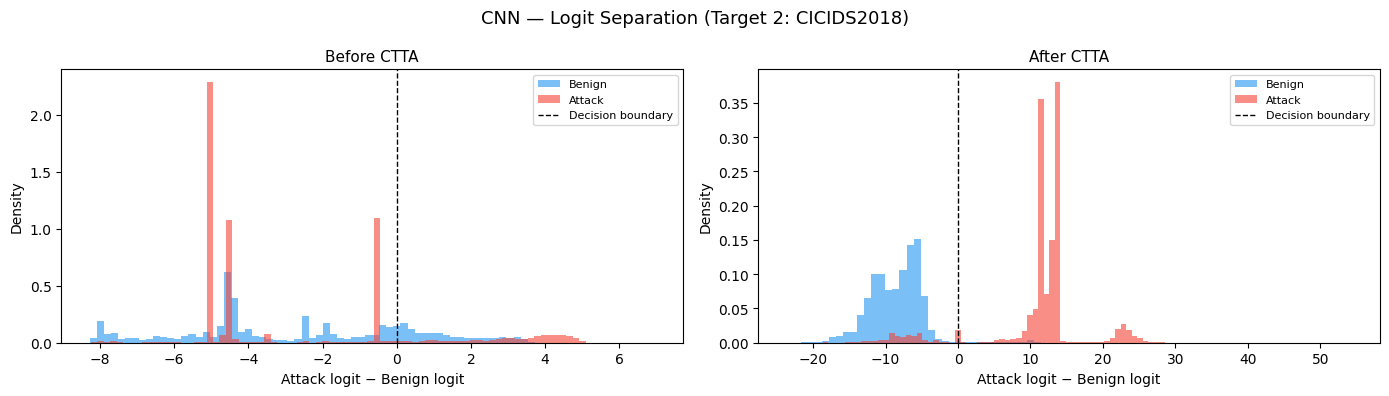

In [ ]:
def plot_logit_separation(model, loader, device, title, ax):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_logits.append(logits.cpu().numpy())
            all_y.append(y.numpy())
    logits = np.concatenate(all_logits)
    y = np.concatenate(all_y)
    margin = logits[:, 1] - logits[:, 0]  # attack logit minus benign logit

    ax.hist(margin[y == 0], bins=80, alpha=0.6, color='#2196F3', label='Benign', density=True)
    ax.hist(margin[y == 1], bins=80, alpha=0.6, color='#F44336', label='Attack', density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Attack logit − Benign logit')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# ── Target 1 ──
model.load_state_dict(model_state)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'{ARCH.upper()} — Logit Separation (Target 1: {TARGET1_NAME})', fontsize=13)

plot_logit_separation(model, stream_tgt1_src_sc, device, 'Before CTTA', axes[0])
_, _, _ = run_ctta(model, stream_tgt1_src_sc, pool_tgt1_src_sc, device)
plot_logit_separation(model, stream_tgt1_src_sc, device, 'After CTTA', axes[1])

plt.tight_layout()
plt.savefig('logit_sep_target1.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Target 2 ──
model.load_state_dict(model_state)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'{ARCH.upper()} — Logit Separation (Target 2: {TARGET2_NAME})', fontsize=13)

plot_logit_separation(model, stream_tgt2_src_sc, device, 'Before CTTA', axes[0])
_, _, _ = run_ctta(model, stream_tgt2_src_sc, pool_tgt2_src_sc, device)
plot_logit_separation(model, stream_tgt2_src_sc, device, 'After CTTA', axes[1])

plt.tight_layout()
plt.savefig('logit_sep_target2.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
def visualize_kan_layer(model, layer_idx, feature_names, ax_row, row_title, top_k=4):
    encoder = model.encoder
    if not hasattr(encoder, 'layers'):
        return
    layer = encoder.layers[layer_idx]

    with torch.no_grad():
        if hasattr(layer, 'scaled_spline_weight'):
            w = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w = layer.spline_weight.cpu().numpy()
        else:
            return
        importance = np.sum(np.abs(w), axis=(0, 2))
        top_indices = np.argsort(importance)[-top_k:][::-1]

    for i, (ax, feat_idx) in enumerate(zip(ax_row, top_indices)):
        x_in = torch.zeros(200, w.shape[1]).to(device)
        x_in[:, feat_idx] = torch.linspace(-1, 1, 200)
        with torch.no_grad():
            out = layer(x_in).cpu().numpy()

        # Find the top 3 most important output neurons for THIS specific input feature
        out_imp = np.sum(np.abs(w[:, feat_idx, :]), axis=-1)
        top_out_idx = np.argsort(out_imp)[-3:][::-1]

        for out_idx in top_out_idx:
            ax.plot(np.linspace(-1, 1, 200), out[:, out_idx], alpha=0.7,
                    label=f'→ h{out_idx}')
        name = feature_names[feat_idx] if feat_idx < len(feature_names) else f'Feature {feat_idx}'
        ax.set_title(f'{name}\n(imp: {importance[feat_idx]:.2f})', fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_ylabel(row_title, fontsize=9, fontweight='bold')
            ax.legend(fontsize=6)
if ARCH == 'kan':
  # Get feature names
  path = kagglehub.dataset_download(SOURCE_DATASET)
  csv_files = [os.path.join(r, f) for r, _, fs in os.walk(path) for f in fs if f.endswith('.csv')]
  df_tmp = pl.scan_csv(csv_files[0]).collect(engine='streaming').head(5)
  df_tmp = engineer_features(df_tmp)
  feature_names = df_tmp.columns
  # For last layer, input features are latent dims — label them generically
  latent_names = [f'Latent {i}' for i in range(64)]
  del df_tmp

  # 4 rows: first layer before, first layer after, last layer before, last layer after
  fig, axes = plt.subplots(4, 4, figsize=(16, 14))
  fig.suptitle(f'KAN Spline Activations — Before vs After CTTA (Target 1: {TARGET1_NAME})', fontsize=13)

  # Before CTTA
  model.load_state_dict(model_state)
  visualize_kan_layer(model, 0, feature_names, axes[0], 'First Layer\n(Before)', top_k=4)
  visualize_kan_layer(model, -1, latent_names, axes[1], 'Last Layer\n(Before)', top_k=4)

  # After CTTA
  _, _, _ = run_ctta(model, stream_tgt1_src_sc, pool_tgt1_src_sc, device)
  visualize_kan_layer(model, 0, feature_names, axes[2], 'First Layer\n(After)', top_k=4)
  visualize_kan_layer(model, -1, latent_names, axes[3], 'Last Layer\n(After)', top_k=4)

  plt.tight_layout()
  plt.savefig('kan_splines_comparison.png', dpi=200, bbox_inches='tight')
  plt.show()
else:
  print('NOT KAN')

NOT KAN


In [ ]:
def get_raw_feature_importance(model, layer_idx):
    layer = model.encoder.layers[layer_idx]
    with torch.no_grad():
        # 1. Spline component
        if hasattr(layer, 'scaled_spline_weight'):
            w_spline = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w_spline = layer.spline_weight.cpu().numpy()
        else:
            w_spline = None

        spline_imp = np.sum(np.abs(w_spline), axis=2) if w_spline is not None else 0

        # 2. Base (linear) component
        if hasattr(layer, 'base_weight') and layer.base_weight is not None:
            w_base = layer.base_weight.cpu().numpy()
            base_imp = np.abs(w_base)
        else:
            base_imp = 0

    return spline_imp + base_imp

def trace_importance_to_features(model, feature_names, top_k=15):
    W1 = get_raw_feature_importance(model, 0)   # (Hidden, Input)
    W2 = get_raw_feature_importance(model, -1)  # (Latent, Hidden)

    if W1 is None or W2 is None:
        return np.zeros(len(feature_names))

    chained = W2 @ W1
    raw_importance = np.sum(chained, axis=0)
    return raw_importance

def get_kan_importance(model, layer_idx):
    imp_matrix = get_raw_feature_importance(model, layer_idx)
    if imp_matrix is not None:
        return np.sum(imp_matrix, axis=0) # Sum across output neurons to get input feature importance
    return None
if ARCH == 'kan':
  latent_names = [f'Latent {i}' for i in range(64)]
  top_k = 15

  # Before CTTA
  model.load_state_dict(model_state)
  imp_before = get_kan_importance(model, -1)

  # After CTTA
  _, _, _ = run_ctta(model, stream_tgt1_src_sc, pool_tgt1_src_sc, device)
  imp_after = get_kan_importance(model, -1)

  # Get union of top features from both
  top_before = set(np.argsort(imp_before)[-top_k:])
  top_after = set(np.argsort(imp_after)[-top_k:])
  top_union = sorted(top_before | top_after, key=lambda i: imp_before[i], reverse=True)[:top_k]

  names = [f'Latent {i}' for i in top_union]
  vals_before = [imp_before[i] for i in top_union]
  vals_after = [imp_after[i] for i in top_union]

  fig, ax = plt.subplots(figsize=(10, 6))
  x = np.arange(len(names))
  width = 0.35
  bars1 = ax.barh(x + width/2, vals_before, width, label='Before CTTA (source)', color='#2196F3', alpha=0.8)
  bars2 = ax.barh(x - width/2, vals_after, width, label=f'After CTTA ({TARGET1_NAME})', color='#F44336', alpha=0.8)
  ax.set_yticks(x)
  ax.set_yticklabels(names, fontsize=9)
  ax.invert_yaxis()
  ax.set_xlabel('Combined Weight Importance (Σ|w_spline| + |w_base|)', fontsize=10)
  ax.set_title(f'{ARCH.upper()} — Feature Importance Shift After CTTA\n(Last Encoder Layer)', fontsize=12)
  ax.legend(fontsize=9)
  ax.grid(True, axis='x', alpha=0.3)

  plt.tight_layout()
  plt.savefig('feature_importance.png', dpi=200, bbox_inches='tight')
  plt.show()
else:
  print('NOT KAN')


NOT KAN


In [ ]:
if ARCH == 'kan':
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
  top_k = 15

  # Before CTTA
  model.load_state_dict(model_state)
  imp_before = trace_importance_to_features(model, feature_names)

  # After CTTA
  _, _, _ = run_ctta(model, stream_tgt1_src_sc, pool_tgt1_src_sc, device)
  imp_after = trace_importance_to_features(model, feature_names)

  # Normalize both to percentages
  imp_before_pct = (imp_before / imp_before.sum()) * 100
  imp_after_pct = (imp_after / imp_after.sum()) * 100

  # ── Left panel: Before CTTA ──
  top_idx_before = np.argsort(imp_before_pct)[-top_k:]
  names_before = [feature_names[i] if i < len(feature_names) else f'Feature {i}' for i in top_idx_before]
  vals_before = imp_before_pct[top_idx_before]

  colors_before = plt.cm.Blues(np.linspace(0.3, 0.9, top_k))
  ax1.barh(range(top_k), vals_before, color=colors_before)
  ax1.set_yticks(range(top_k))
  ax1.set_yticklabels(names_before, fontsize=9)
  ax1.set_xlabel('Importance (%)', fontsize=10)
  ax1.set_title(f'Before CTTA\n(Source: {SOURCE_NAME})', fontsize=12, fontweight='bold')
  ax1.grid(True, axis='x', alpha=0.3)
  for i, v in enumerate(vals_before):
      ax1.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

  # ── Right panel: After CTTA ──
  top_idx_after = np.argsort(imp_after_pct)[-top_k:]
  names_after = [feature_names[i] if i < len(feature_names) else f'Feature {i}' for i in top_idx_after]
  vals_after = imp_after_pct[top_idx_after]

  colors_after = plt.cm.Reds(np.linspace(0.3, 0.9, top_k))
  ax2.barh(range(top_k), vals_after, color=colors_after)
  ax2.set_yticks(range(top_k))
  ax2.set_yticklabels(names_after, fontsize=9)
  ax2.set_xlabel('Importance (%)', fontsize=10)
  ax2.set_title(f'After CTTA\n(Target: {TARGET1_NAME})', fontsize=12, fontweight='bold')
  ax2.grid(True, axis='x', alpha=0.3)
  for i, v in enumerate(vals_after):
      ax2.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

  fig.suptitle(f'{ARCH.upper()} — Feature Importance Ranking (Traced Through Full Encoder)', fontsize=13, y=1.02)
  plt.tight_layout()
  plt.savefig('feature_importance_separate.png', dpi=200, bbox_inches='tight')
  plt.show()
else:
  print('NOT KAN')

NOT KAN


In [ ]:
import plotly.graph_objects as go

def plot_importance_sankey(model, feature_names, title):
    W1 = get_raw_feature_importance(model, 0)   # (64, 49)
    W2 = get_raw_feature_importance(model, -1)   # (32, 64)

    # Pick top nodes per layer
    input_imp = W1.sum(axis=0)
    top_inputs = np.argsort(input_imp)[-8:][::-1]

    hidden_imp = W1.sum(axis=1) + W2.sum(axis=0)
    top_hidden = np.argsort(hidden_imp)[-8:][::-1]

    latent_imp = W2.sum(axis=1)
    top_latents = np.argsort(latent_imp)[-6:][::-1]

    n_i = len(top_inputs)
    n_h = len(top_hidden)
    n_l = len(top_latents)
    total = n_i + n_h + n_l

    # Labels
    input_labels = [feature_names[i] if i < len(feature_names) else f'Feat {i}' for i in top_inputs]
    hidden_labels = [f'Hidden {i}' for i in top_hidden]
    latent_labels = [f'Latent {i}' for i in top_latents]
    all_labels = input_labels + hidden_labels + latent_labels

    # Force 3-column layout with explicit x positions
    x_pos = [0.01] * n_i + [0.5] * n_h + [0.99] * n_l

    # Spread nodes vertically within each column
    def spread(n):
        if n == 1:
            return [0.5]
        return [0.05 + 0.9 * i / (n - 1) for i in range(n)]

    y_pos = spread(n_i) + spread(n_h) + spread(n_l)

    # Colors
    node_colors = ['rgba(33, 150, 243, 0.8)'] * n_i + \
                  ['rgba(156, 39, 176, 0.8)'] * n_h + \
                  ['rgba(244, 67, 54, 0.8)'] * n_l

    sources, targets, values, link_colors = [], [], [], []

    # Layer 1: input → hidden
    for hi, h_idx in enumerate(top_hidden):
        for ii, i_idx in enumerate(top_inputs):
            w = W1[h_idx, i_idx]
            if w > 0.1:
                sources.append(ii)
                targets.append(n_i + hi)
                values.append(float(w))
                link_colors.append('rgba(33, 150, 243, 0.12)')

    # Layer 2: hidden → latent
    for li, l_idx in enumerate(top_latents):
        for hi, h_idx in enumerate(top_hidden):
            w = W2[l_idx, h_idx]
            if w > 0.05:
                sources.append(n_i + hi)
                targets.append(n_i + n_h + li)
                values.append(float(w))
                link_colors.append('rgba(244, 67, 54, 0.12)')

    fig = go.Figure(data=[go.Sankey(
        arrangement='fixed',
        node=dict(
            pad=20,
            thickness=15,
            line=dict(color='black', width=0.5),
            label=all_labels,
            color=node_colors,
            x=x_pos,
            y=y_pos,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
        )
    )])

    fig.update_layout(
        title_text=title,
        font_size=11,
        width=1000,
        height=550,
        annotations=[
            dict(x=0.01, y=1.08, text='<b>Input Features</b>', showarrow=False,
                 font=dict(size=12, color='#2196F3'), xref='paper', yref='paper'),
            dict(x=0.5, y=1.08, text='<b>Hidden Layer</b>', showarrow=False,
                 font=dict(size=12, color='#9C27B0'), xref='paper', yref='paper'),
            dict(x=0.99, y=1.08, text='<b>Latent Layer</b>', showarrow=False,
                 font=dict(size=12, color='#F44336'), xref='paper', yref='paper'),
        ]
    )
    fig.show()

if ARCH == 'kan':
  # Before CTTA
  model.load_state_dict(model_state)
  plot_importance_sankey(
      model, feature_names,
      f'KAN Encoder — Importance Flow (Before CTTA: Source {SOURCE_NAME})'
  )

  # After CTTA
  _, _, _ = run_ctta(model, stream_tgt1_src_sc, pool_tgt1_src_sc, device)
  plot_importance_sankey(
      model, feature_names,
      f'KAN Encoder — Importance Flow (After CTTA: Target {TARGET1_NAME})'
  )
else:
  print('NOT KAN')

NOT KAN


In [ ]:
print(f'Device={device} | Arch={ARCH} | [SOURCE]={SOURCE_NAME} | Size={SAMPLE_N} | Last Layer={SPLINE_TRUE}')
print(f"Last exec: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%SZ')}")

Device=cpu | Arch=cnn | [SOURCE]=ToN-IoT | Size=1000000 | Last Layer=True
Last exec: 2026-05-14 05:36:56Z
